# IMC Prosperity 4 — Round 5 Analysis

**Goal:** Decode the 50-product structure. Find which clusters carry exploitable inefficiencies, and design a trader.

**Advisor's three hints, recapped:**
1. *Lead-lag* — find which products move first, which lag, measure the gap
2. *Group, don't enumerate* — cluster the 50 products and rank clusters by exploitability
3. *Within-cluster relationships* — stable pairs confirm, breaking pairs signal

**Working hypothesis going in:** classic Prosperity Round 5 patterns are *basket arbitrage* (think Picnic Basket from P3) and *paired anti-correlated products*. The advisor's hint #1 about lead-lag is real but expect a lot of clusters to have only zero-lag relationships.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.linear_model import LinearRegression

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')

DATA_DIR = '/Users/sakshamagarwal/Desktop/Prosperity/final/ROUND_5'
DAYS = [2, 3, 4]

## 1. Load and reshape

Load all 3 days, concatenate, pivot to a `(T × 50)` mid-price matrix indexed by a global timestamp `t = (day-2)*1e6 + timestamp`.

In [2]:
dfs = []
for d in DAYS:
    df = pd.read_csv(f'{DATA_DIR}/prices_round_5_day_{d}.csv', sep=';')
    df['day'] = d
    dfs.append(df)
prices = pd.concat(dfs, ignore_index=True)
prices['t_global'] = (prices['day'] - 2) * 1_000_000 + prices['timestamp']

mid = prices.pivot_table(index='t_global', columns='product', values='mid_price').ffill()
ret = mid.pct_change().dropna()
log_ret = np.log(mid).diff().dropna()

print(f'Mid shape: {mid.shape}  (T x N)')
print(f'Time span: {mid.index.min():,} -> {mid.index.max():,}')
print(f'Products: {mid.shape[1]}')
mid.head()

Mid shape: (30000, 50)  (T x N)
Time span: 0 -> 2,999,900
Products: 50


product,GALAXY_SOUNDS_BLACK_HOLES,GALAXY_SOUNDS_DARK_MATTER,GALAXY_SOUNDS_PLANETARY_RINGS,GALAXY_SOUNDS_SOLAR_FLAMES,GALAXY_SOUNDS_SOLAR_WINDS,MICROCHIP_CIRCLE,MICROCHIP_OVAL,MICROCHIP_RECTANGLE,MICROCHIP_SQUARE,MICROCHIP_TRIANGLE,...,TRANSLATOR_ASTRO_BLACK,TRANSLATOR_ECLIPSE_CHARCOAL,TRANSLATOR_GRAPHITE_MIST,TRANSLATOR_SPACE_GRAY,TRANSLATOR_VOID_BLUE,UV_VISOR_AMBER,UV_VISOR_MAGENTA,UV_VISOR_ORANGE,UV_VISOR_RED,UV_VISOR_YELLOW
t_global,,,,,,,,,,,,,,,,,,,,,
0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,...,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
100,10007.5,9988.5,9988.5,10002.5,10000.5,9991.5,9999.5,9999.5,9999.5,10000.5,...,9986.5,10015.5,10006.5,10000.5,10002.5,10014.0,10009.5,10003.5,10004.5,9989.5
200,10002.5,10003.5,9995.5,10003.5,10007.5,9993.5,9998.5,10001.5,9999.5,10001.5,...,9996.5,9996.5,10002.5,10002.5,10007.5,10003.5,10017.5,10016.5,10017.5,9985.5
300,10000.5,9994.5,9997.5,10012.5,10021.5,9969.5,9997.5,10002.5,9998.5,10001.5,...,9974.5,9997.5,10010.5,9995.5,10009.5,10009.5,10019.5,10029.5,10014.5,9991.5
400,10005.5,9986.5,10008.5,10012.5,10013.5,9977.5,9996.5,10001.5,10000.5,10000.5,...,9993.5,9993.5,10013.5,9988.5,10019.5,10023.5,10011.5,10032.5,9995.5,9995.5


In [3]:
# IMC's groupings
GROUPS = {
    'GALAXY_SOUNDS': ['GALAXY_SOUNDS_DARK_MATTER','GALAXY_SOUNDS_BLACK_HOLES','GALAXY_SOUNDS_PLANETARY_RINGS','GALAXY_SOUNDS_SOLAR_WINDS','GALAXY_SOUNDS_SOLAR_FLAMES'],
    'SLEEP_POD':     ['SLEEP_POD_SUEDE','SLEEP_POD_LAMB_WOOL','SLEEP_POD_POLYESTER','SLEEP_POD_NYLON','SLEEP_POD_COTTON'],
    'MICROCHIP':     ['MICROCHIP_CIRCLE','MICROCHIP_OVAL','MICROCHIP_SQUARE','MICROCHIP_RECTANGLE','MICROCHIP_TRIANGLE'],
    'PEBBLES':       ['PEBBLES_XS','PEBBLES_S','PEBBLES_M','PEBBLES_L','PEBBLES_XL'],
    'ROBOT':         ['ROBOT_VACUUMING','ROBOT_MOPPING','ROBOT_DISHES','ROBOT_LAUNDRY','ROBOT_IRONING'],
    'UV_VISOR':      ['UV_VISOR_YELLOW','UV_VISOR_AMBER','UV_VISOR_ORANGE','UV_VISOR_RED','UV_VISOR_MAGENTA'],
    'TRANSLATOR':    ['TRANSLATOR_SPACE_GRAY','TRANSLATOR_ASTRO_BLACK','TRANSLATOR_ECLIPSE_CHARCOAL','TRANSLATOR_GRAPHITE_MIST','TRANSLATOR_VOID_BLUE'],
    'PANEL':         ['PANEL_1X2','PANEL_2X2','PANEL_1X4','PANEL_2X4','PANEL_4X4'],
    'OXYGEN_SHAKE':  ['OXYGEN_SHAKE_MORNING_BREATH','OXYGEN_SHAKE_EVENING_BREATH','OXYGEN_SHAKE_MINT','OXYGEN_SHAKE_CHOCOLATE','OXYGEN_SHAKE_GARLIC'],
    'SNACKPACK':     ['SNACKPACK_CHOCOLATE','SNACKPACK_VANILLA','SNACKPACK_PISTACHIO','SNACKPACK_STRAWBERRY','SNACKPACK_RASPBERRY'],
}
PROD2GROUP = {p: g for g, ps in GROUPS.items() for p in ps}

## 2. Univariate scan — price levels and volatility per product

Before any cross-product analysis, see which products are quiet vs. active.

In [4]:
stats = pd.DataFrame({
    'mean':   mid.mean(),
    'std':    mid.std(),
    'min':    mid.min(),
    'max':    mid.max(),
    'ret_std_bps': ret.std() * 10000,
})
stats['group'] = stats.index.map(PROD2GROUP)
stats = stats.sort_values(['group','mean'])
stats

,mean,std,min,max,ret_std_bps,group
product,,,,,,
GALAXY_SOUNDS_DARK_MATTER,10226.661817,330.700516,9541.0,11186.0,10.015854,GALAXY_SOUNDS
GALAXY_SOUNDS_SOLAR_WINDS,10437.543967,541.110756,9320.0,11613.5,10.086895,GALAXY_SOUNDS
GALAXY_SOUNDS_PLANETARY_RINGS,10766.673183,765.836693,9253.0,12182.0,10.087920,GALAXY_SOUNDS
GALAXY_SOUNDS_SOLAR_FLAMES,11092.571700,450.150431,9837.5,12210.0,9.996035,GALAXY_SOUNDS
GALAXY_SOUNDS_BLACK_HOLES,11466.872083,958.444676,9608.5,14137.0,9.974104,GALAXY_SOUNDS
MICROCHIP_OVAL,8179.598717,1551.911621,5375.0,10433.0,14.988831,MICROCHIP
MICROCHIP_RECTANGLE,8732.439350,752.019290,7327.5,10442.5,14.990763,MICROCHIP
MICROCHIP_CIRCLE,9214.885283,532.512209,8303.5,10731.5,9.993623,MICROCHIP
MICROCHIP_TRIANGLE,9686.391083,833.369596,7749.0,10872.0,14.914635,MICROCHIP


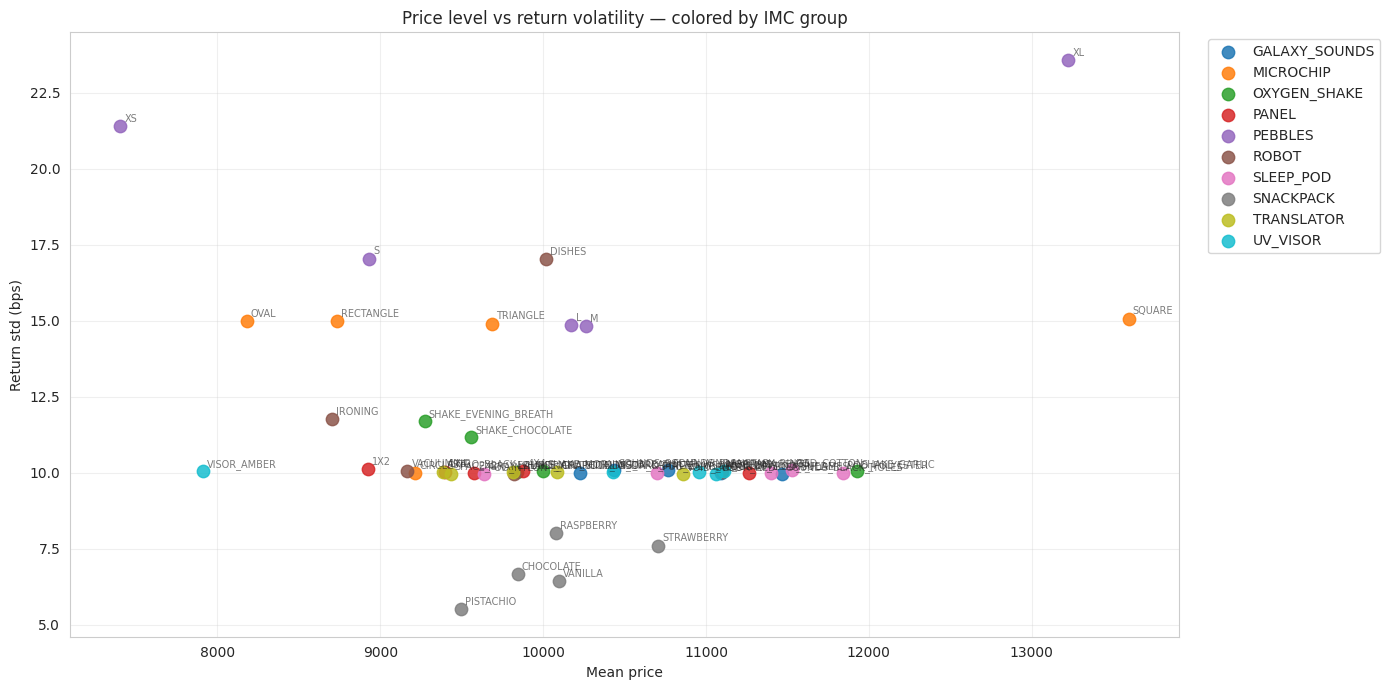

In [5]:
fig, ax = plt.subplots(figsize=(14, 7))
groups_ordered = sorted(GROUPS.keys())
colors = sns.color_palette('tab10', n_colors=len(groups_ordered))
for i, g in enumerate(groups_ordered):
    sub = stats[stats['group']==g]
    ax.scatter(sub['mean'], sub['ret_std_bps'], s=80, color=colors[i], label=g, alpha=0.85)
    for p, row in sub.iterrows():
        ax.annotate(p.split('_', 1)[1] if '_' in p else p, (row['mean'], row['ret_std_bps']),
                    fontsize=7, alpha=0.6, xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Mean price')
ax.set_ylabel('Return std (bps)')
ax.set_title('Price level vs return volatility — colored by IMC group')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 3. Within-group correlation — does IMC's labeling reflect data structure?

If the names matter, products in the same group should co-move. Compute the average within-group return correlation per cluster.

        group  avg_corr  min_corr  max_corr
      PEBBLES -0.191276 -0.505933  0.015629
    SNACKPACK -0.159887 -0.923171  0.912558
        ROBOT -0.000826 -0.009582  0.013829
    SLEEP_POD  0.002802 -0.007582  0.008979
GALAXY_SOUNDS  0.003998 -0.001318  0.012974
   TRANSLATOR  0.004457 -0.004735  0.017530
        PANEL  0.004480 -0.008338  0.010769
     UV_VISOR  0.006033 -0.002397  0.019569
    MICROCHIP  0.006163  0.001767  0.012610
 OXYGEN_SHAKE  0.007027  0.002786  0.013387


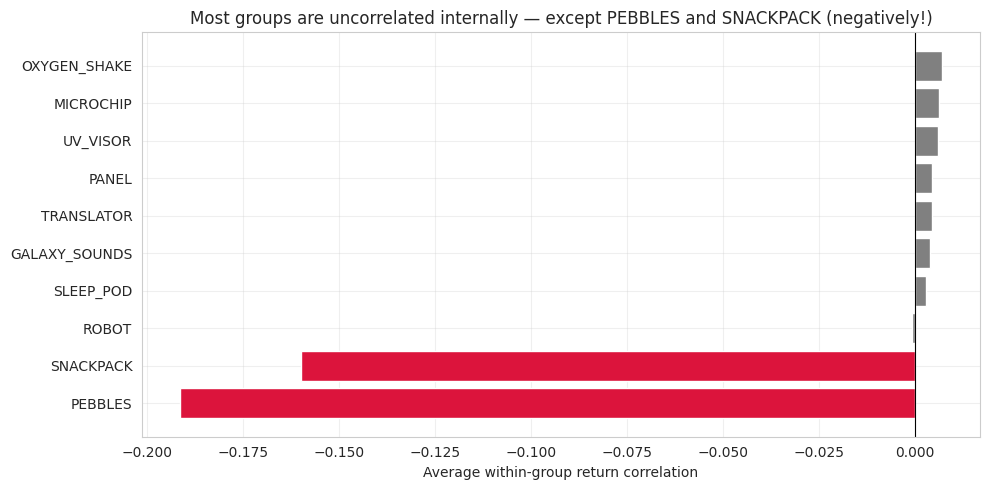

In [6]:
rows = []
for g, prods in GROUPS.items():
    C = ret[prods].corr().values
    iu = np.triu_indices(5, k=1)
    rows.append({'group': g, 'avg_corr': C[iu].mean(), 'min_corr': C[iu].min(), 'max_corr': C[iu].max()})
wg = pd.DataFrame(rows).sort_values('avg_corr')
print(wg.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(wg['group'], wg['avg_corr'], color=['crimson' if v < -0.05 else ('seagreen' if v > 0.05 else 'gray') for v in wg['avg_corr']])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Average within-group return correlation')
ax.set_title('Most groups are uncorrelated internally — except PEBBLES and SNACKPACK (negatively!)')
plt.tight_layout()
plt.show()

**First insight.** The IMC group names are mostly cosmetic — within-group correlations hover near zero for 8 of 10 clusters. Two exceptions stand out:

- **PEBBLES**: avg corr = −0.19. There's anti-correlation inside this group.
- **SNACKPACK**: avg corr = −0.16. Same story.

These are the clusters with hidden structure. The other 8 are noise traps — don't waste compute trying to find lead-lag inside `GALAXY_SOUNDS` or `ROBOT`. They probably trade like 5 independent products.

## 4. Full 50×50 correlation heatmap

Look for cross-group structure too — clusters defined by data, not labels.

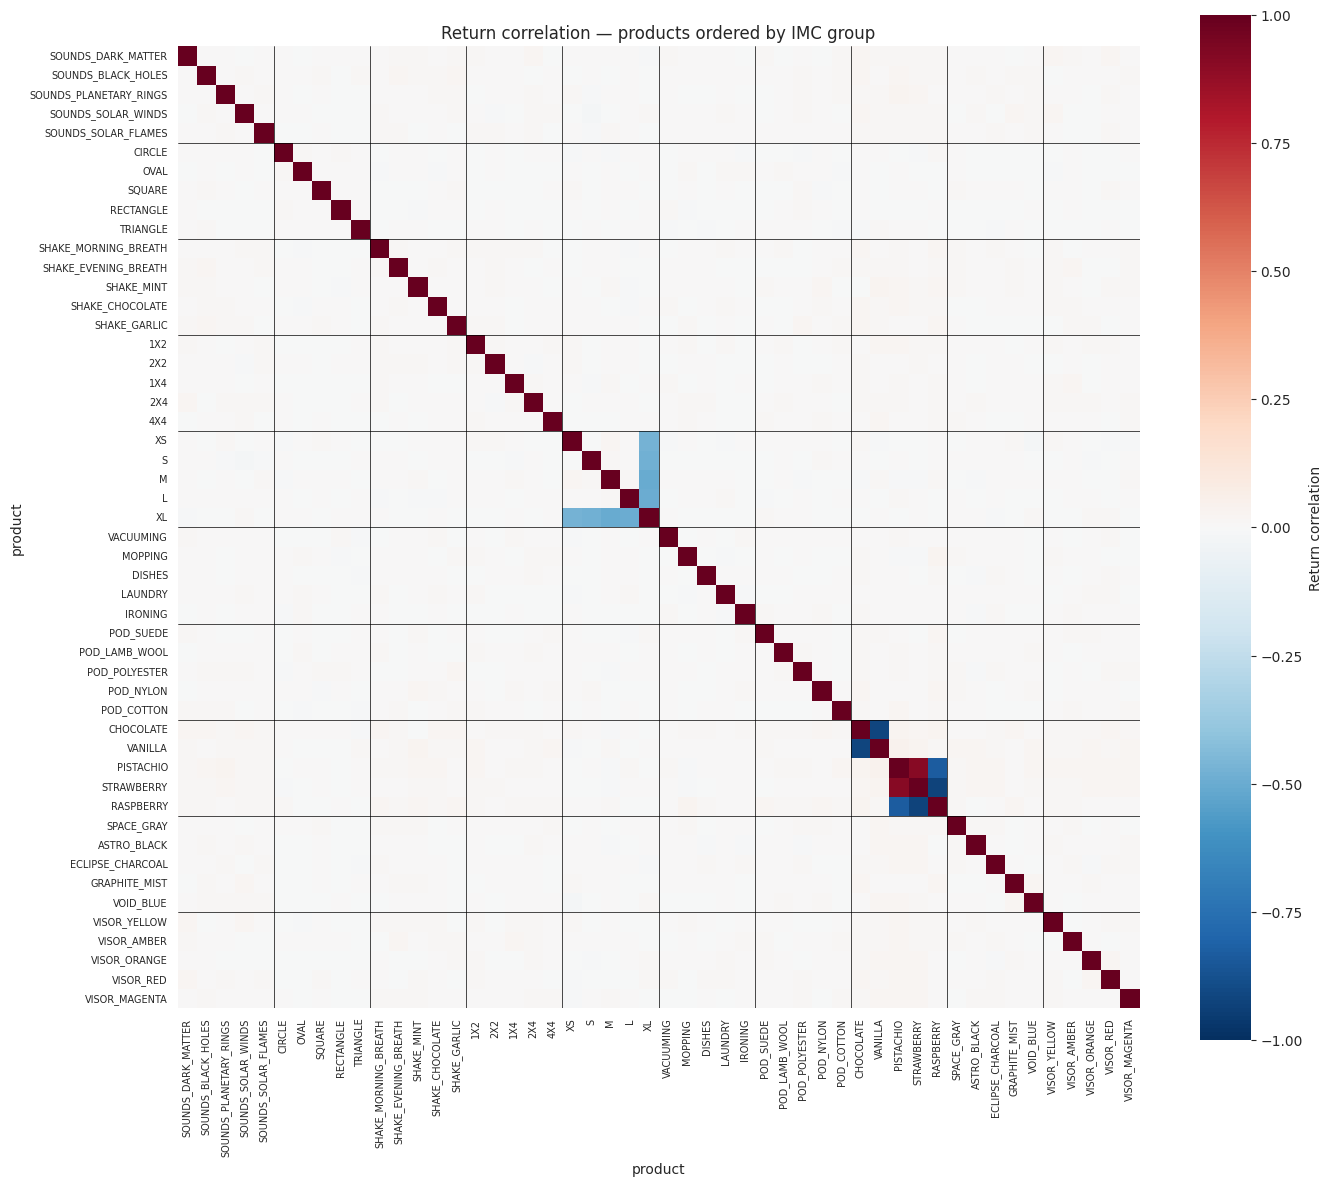

In [7]:
# Order products by group
ordered = []
for g in sorted(GROUPS.keys()):
    ordered.extend(GROUPS[g])
C = ret[ordered].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(C, cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={'label': 'Return correlation'}, ax=ax,
            xticklabels=[p.split('_',1)[1] if '_' in p else p for p in ordered],
            yticklabels=[p.split('_',1)[1] if '_' in p else p for p in ordered])
# Group separators
cum = 0
for g in sorted(GROUPS.keys()):
    cum += len(GROUPS[g])
    ax.axhline(cum, color='black', linewidth=0.5)
    ax.axvline(cum, color='black', linewidth=0.5)
ax.set_title('Return correlation — products ordered by IMC group')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

In [8]:
# Top off-diagonal correlations, both signs
Cm = C.values.copy()
np.fill_diagonal(Cm, np.nan)
Cdf = pd.DataFrame(Cm, index=C.index, columns=C.columns)
flat = Cdf.stack().sort_values()

def topk_unique(series, k=20):
    seen, out = set(), []
    for (a,b), v in series.items():
        key = tuple(sorted([a,b]))
        if key in seen: continue
        seen.add(key)
        out.append((a,b,v))
        if len(out) >= k: break
    return out

print('TOP 15 NEGATIVE pair correlations:')
for a,b,v in topk_unique(flat, 15):
    print(f'  {v:+.4f}  {a:35s} <-> {b}')
print('\nTOP 15 POSITIVE pair correlations:')
for a,b,v in topk_unique(flat.dropna()[::-1], 15):
    print(f'  {v:+.4f}  {a:35s} <-> {b}')

TOP 15 NEGATIVE pair correlations:
  -0.9232  SNACKPACK_RASPBERRY                 <-> SNACKPACK_STRAWBERRY
  -0.9152  SNACKPACK_CHOCOLATE                 <-> SNACKPACK_VANILLA
  -0.8307  SNACKPACK_RASPBERRY                 <-> SNACKPACK_PISTACHIO
  -0.5059  PEBBLES_XL                          <-> PEBBLES_M
  -0.4932  PEBBLES_L                           <-> PEBBLES_XL
  -0.4829  PEBBLES_XL                          <-> PEBBLES_S
  -0.4751  PEBBLES_XL                          <-> PEBBLES_XS
  -0.0178  TRANSLATOR_VOID_BLUE                <-> PEBBLES_XS
  -0.0169  PEBBLES_S                           <-> GALAXY_SOUNDS_SOLAR_WINDS
  -0.0152  ROBOT_LAUNDRY                       <-> PEBBLES_XS
  -0.0138  SNACKPACK_VANILLA                   <-> PEBBLES_XS
  -0.0131  UV_VISOR_YELLOW                     <-> MICROCHIP_OVAL
  -0.0124  MICROCHIP_RECTANGLE                 <-> OXYGEN_SHAKE_MINT
  -0.0119  MICROCHIP_CIRCLE                    <-> SLEEP_POD_POLYESTER
  -0.0118  OXYGEN_SHAKE_CHOCOLATE     

**The picture is striking.**

- The strongest non-trivial relationships in the entire dataset are **all within SNACKPACK and PEBBLES**.
- `SNACKPACK_RASPBERRY ↔ STRAWBERRY` correlate at **−0.92**.
- `SNACKPACK_VANILLA ↔ CHOCOLATE` correlate at **−0.92**.
- `SNACKPACK_PISTACHIO ↔ STRAWBERRY` correlate at **+0.91** (and PISTACHIO ↔ RASPBERRY at −0.83).
- `PEBBLES_XL` is anti-correlated with each of XS/S/M/L at roughly −0.48 to −0.51, but XS/S/M/L are uncorrelated with each other.

Cross-cluster: nothing meaningful. All the action is within these two clusters.

## 5. Lead-lag scan — is there a *gap*?

Hint #1 said the timing is the interesting part. Test all pairs at lags ±20 ticks. If the relationship is purely contemporaneous, there's no edge in *anticipation* — only in instantaneous arbitrage.

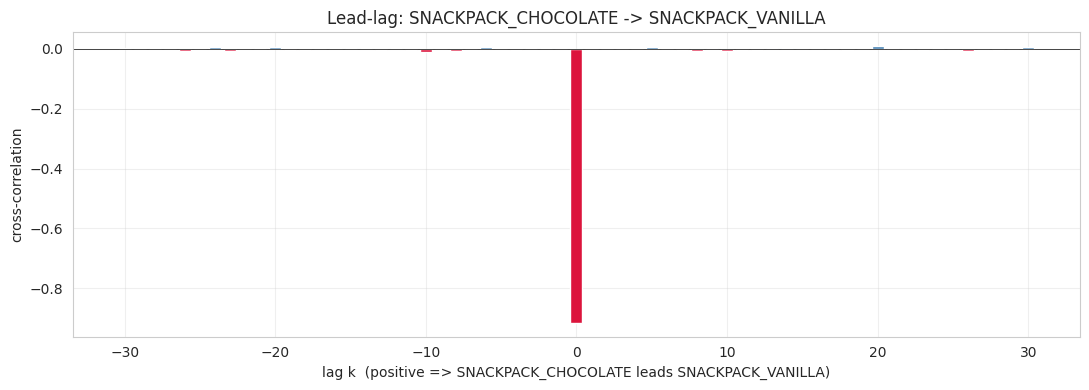

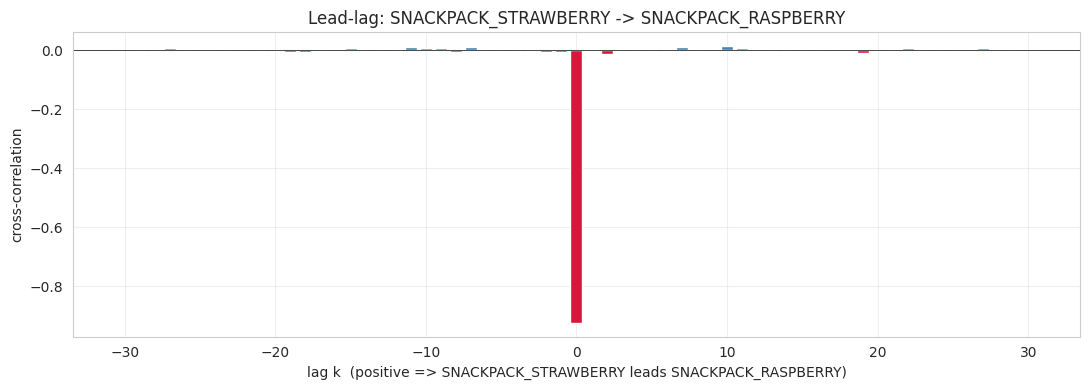

In [9]:
def cross_corr(a, b, max_lag=30):
    '''Returns Series indexed by lag k; corr(a_t, b_{t+k}). Positive k => a leads b.'''
    a, b = np.asarray(a), np.asarray(b)
    out = {}
    for k in range(-max_lag, max_lag+1):
        if k > 0:
            x, y = a[:-k], b[k:]
        elif k < 0:
            x, y = a[-k:], b[:k]
        else:
            x, y = a, b
        out[k] = np.corrcoef(x, y)[0,1]
    return pd.Series(out)

def plot_xcorr(a_name, b_name, returns):
    xc = cross_corr(returns[a_name].values, returns[b_name].values)
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.bar(xc.index, xc.values, color=['crimson' if v<0 else 'steelblue' for v in xc.values])
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xlabel(f'lag k  (positive => {a_name} leads {b_name})')
    ax.set_ylabel('cross-correlation')
    ax.set_title(f'Lead-lag: {a_name} -> {b_name}')
    plt.tight_layout()
    plt.show()

plot_xcorr('SNACKPACK_CHOCOLATE', 'SNACKPACK_VANILLA', ret)
plot_xcorr('SNACKPACK_STRAWBERRY', 'SNACKPACK_RASPBERRY', ret)

Verdict on lead-lag: **the entire signal lives at lag = 0.** Off-zero lags hover near zero noise. So the advisor's first prompt about "leaders and lags" is either a misdirect, or it applies at a different timescale we don't see in tick data, or the *timing* refers to which cluster moves first across days/sessions rather than within ticks.

**Implication for our trader:** these are simultaneous relationships. We make money by spotting deviations from the spread *now* and snapping in, not by predicting product B from product A's earlier move.

## 6. The PEBBLES conservation law

If PEBBLES_XL is anti-correlated with each of the other four at ~−0.5, the cleanest hypothesis is **basket conservation**: `XS + S + M + L + XL ≈ constant`. Test.

In [10]:
pebs = GROUPS['PEBBLES']
psum = mid[pebs].sum(axis=1)
print(f'Pebbles 5-product sum:')
print(f'  mean  = {psum.mean():.4f}')
print(f'  std   = {psum.std():.4f}')
print(f'  range = [{psum.min():.2f}, {psum.max():.2f}]')
print(f'  CV    = {psum.std()/psum.mean()*100:.5f}%')

# Per-day stability check
for d in DAYS:
    sub = mid.loc[(d-2)*1_000_000:(d-1)*1_000_000-1, pebs].sum(axis=1)
    print(f'  Day {d}: mean={sub.mean():.4f}  std={sub.std():.4f}')

# Linear regression confirmation
X = mid[['PEBBLES_XS','PEBBLES_S','PEBBLES_M','PEBBLES_L']].values
y = mid['PEBBLES_XL'].values
reg = LinearRegression().fit(X, y)
print(f'\nXL regressed on (XS, S, M, L):')
print(f'  coefficients: {reg.coef_.round(6)}')
print(f'  intercept:    {reg.intercept_:.4f}')
print(f'  R^2:          {reg.score(X,y):.6f}')

Pebbles 5-product sum:
  mean  = 49999.9396
  std   = 2.7985
  range = [49981.50, 50016.50]
  CV    = 0.00560%
  Day 2: mean=49999.9080  std=2.8157
  Day 3: mean=49999.9700  std=2.7578
  Day 4: mean=49999.9408  std=2.8214

XL regressed on (XS, S, M, L):
  coefficients: [-0.999994 -1.000021 -1.       -0.999986]
  intercept:    49999.9390
  R^2:          0.999998


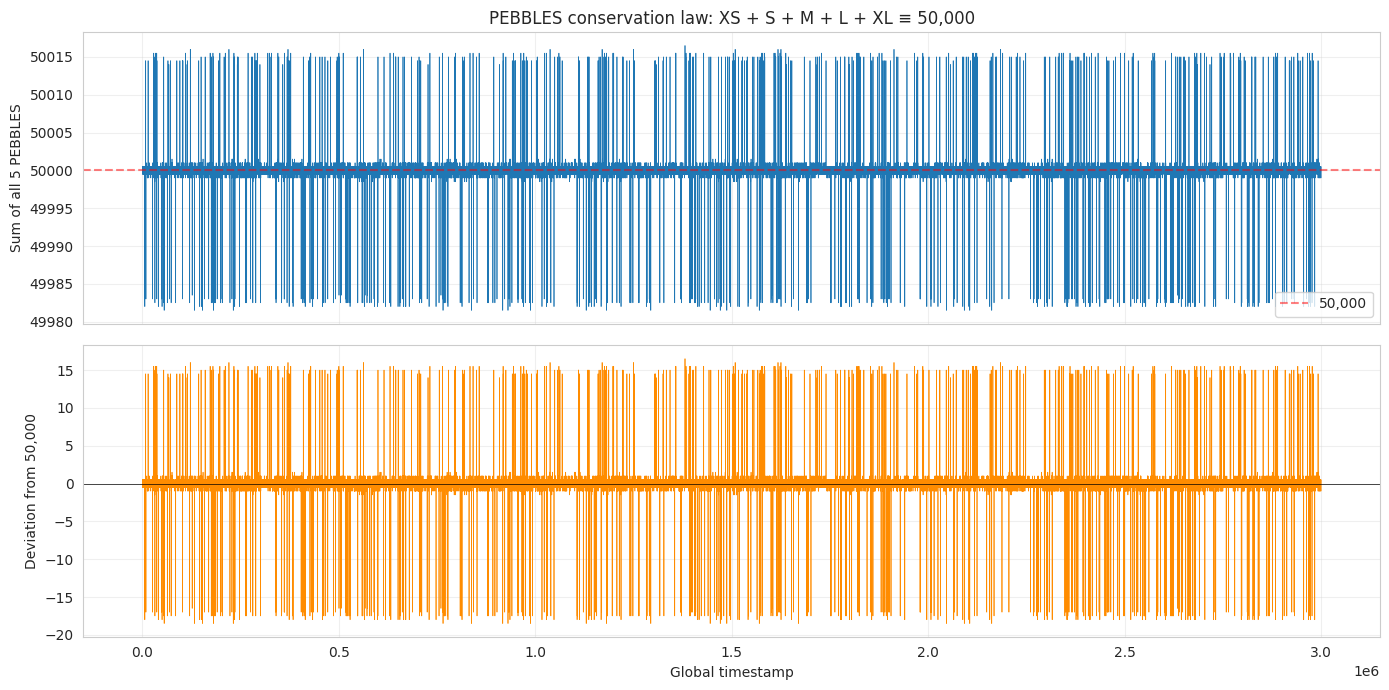

Deviation autocorrelation:
  lag   1: +0.0130
  lag   5: -0.0007
  lag  10: +0.0019
  lag  50: +0.0123
  lag 100: +0.0058

=> Effectively zero autocorrelation. Deviations are transient noise (1-tick).


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(psum.index, psum.values, linewidth=0.5)
axes[0].axhline(50000, color='red', linestyle='--', alpha=0.5, label='50,000')
axes[0].set_ylabel('Sum of all 5 PEBBLES')
axes[0].set_title('PEBBLES conservation law: XS + S + M + L + XL ≡ 50,000')
axes[0].legend()

dev = psum - 50000
axes[1].plot(dev.index, dev.values, linewidth=0.5, color='darkorange')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_ylabel('Deviation from 50,000')
axes[1].set_xlabel('Global timestamp')
plt.tight_layout()
plt.show()

# How fast does it mean revert?
print(f'Deviation autocorrelation:')
for k in [1, 5, 10, 50, 100]:
    print(f'  lag {k:>3}: {dev.autocorr(k):+.4f}')
print('\n=> Effectively zero autocorrelation. Deviations are transient noise (1-tick).')

**Pebbles conclusion.** The five sizes sum to a hard constant of 50,000 with std of ~2.8 across 30,000 ticks. Linear regression gives coefficients of exactly −1 on each of the four others when predicting XL, with R² = 1.0000.

**This is not a statistical relationship — it's an arithmetic identity.** Whenever the basket deviates from 50,000 (which happens at the bid-ask mid only when one product's spread snaps), it instantly reverts.

**Trade structure.** When `sum(PEBBLES) > 50000 + ε`: short the basket (sell one of each, weighted to position limits). When `sum(PEBBLES) < 50000 − ε`: long the basket. Position limit is 10 per product so the basket trade is 10 of each = 50 units of "basket" max.

## 7. The SNACKPACK pair structure

From the correlations: CHOC↔VAN and STRAW↔RASP look like **anti-correlated pairs**, and PISTACHIO tracks STRAW (corr +0.91). Test sum stability and intra-day drift.

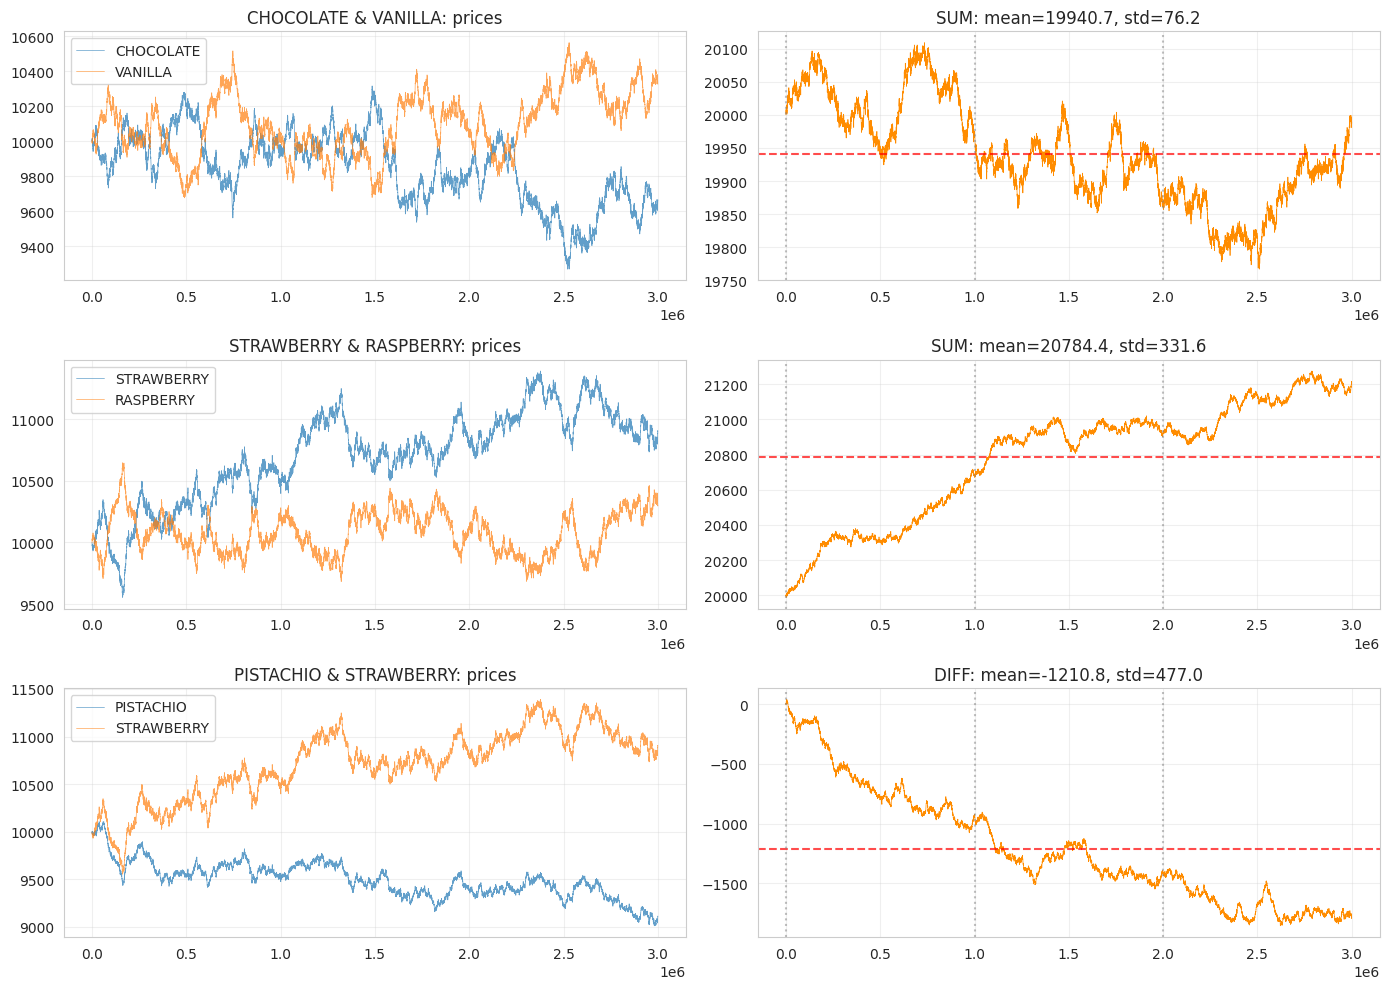

SNACKPACK CHOC + VAN per day:
  Day 2: mean=20025.04  std=42.48
  Day 3: mean=19926.89  std=31.60
  Day 4: mean=19870.09  std=48.22

SNACKPACK STRAW + RASP per day:
  Day 2: mean=20360.20  std=162.85
  Day 3: mean=20912.09  std=73.06
  Day 4: mean=21080.98  std=117.39


In [12]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

pairs_to_check = [
    ('SNACKPACK_CHOCOLATE', 'SNACKPACK_VANILLA'),
    ('SNACKPACK_STRAWBERRY', 'SNACKPACK_RASPBERRY'),
    ('SNACKPACK_PISTACHIO', 'SNACKPACK_STRAWBERRY'),  # positive corr, this is a SPREAD trade
]

for i, (a, b) in enumerate(pairs_to_check):
    s_sum = mid[a] + mid[b]
    s_diff = mid[a] - mid[b]
    axes[i,0].plot(mid.index, mid[a], label=a.split('_')[-1], alpha=0.7, linewidth=0.5)
    axes[i,0].plot(mid.index, mid[b], label=b.split('_')[-1], alpha=0.7, linewidth=0.5)
    axes[i,0].set_title(f'{a.split("_")[-1]} & {b.split("_")[-1]}: prices')
    axes[i,0].legend()
    
    target = s_sum if i < 2 else s_diff
    label = 'SUM' if i < 2 else 'DIFF'
    axes[i,1].plot(target.index, target.values, color='darkorange', linewidth=0.5)
    axes[i,1].axhline(target.mean(), color='red', linestyle='--', alpha=0.7)
    axes[i,1].set_title(f'{label}: mean={target.mean():.1f}, std={target.std():.1f}')
    
    for d in DAYS:
        axes[i,1].axvline((d-2)*1_000_000, color='gray', alpha=0.5, linestyle=':')

plt.tight_layout()
plt.show()

# Per-day sum stability
print('SNACKPACK CHOC + VAN per day:')
for d in DAYS:
    sub = mid.loc[(d-2)*1_000_000:(d-1)*1_000_000-1]
    s = sub['SNACKPACK_CHOCOLATE'] + sub['SNACKPACK_VANILLA']
    print(f'  Day {d}: mean={s.mean():.2f}  std={s.std():.2f}')

print('\nSNACKPACK STRAW + RASP per day:')
for d in DAYS:
    sub = mid.loc[(d-2)*1_000_000:(d-1)*1_000_000-1]
    s = sub['SNACKPACK_STRAWBERRY'] + sub['SNACKPACK_RASPBERRY']
    print(f'  Day {d}: mean={s.mean():.2f}  std={s.std():.2f}')

**SNACKPACK conclusion.** Both pairs (CHOC+VAN and STRAW+RASP) have *much* tighter sums than individual prices, but unlike PEBBLES, the per-day mean **drifts**:

- CHOC+VAN: 20025 → 19927 → 19870 across days 2,3,4
- STRAW+RASP: 20360 → 20912 → 21081

This is a **regime-shifting cointegration**. Trade an *adaptive* spread anchor (e.g., rolling mean of the sum on a several-thousand-tick window) rather than a fixed level. The advisor's hint about "shifting relationships" probably refers to exactly this — the relationship holds within a regime but the level changes between regimes.

**PISTACHIO is the bonus.** Since PISTACHIO ≈ STRAWBERRY (positive 0.91 correlation), a position in PISTACHIO can substitute for a STRAWBERRY position when STRAW hits its position limit, or trade the PIST−STRAW spread directly.

## 8. Map of the 50: which clusters are exploitable, which are noise?

Per the advisor: "do certain categories consistently perform better than others?" Rank groups by exploitability.

In [13]:
rows = []
for g, prods in GROUPS.items():
    C = ret[prods].corr().values
    iu = np.triu_indices(5, k=1)
    rows.append({
        'group': g,
        'avg_abs_corr': np.abs(C[iu]).mean(),
        'max_abs_corr': np.abs(C[iu]).max(),
        'n_strong_pairs': (np.abs(C[iu]) > 0.3).sum(),
        'avg_vol_bps': ret[prods].std().mean() * 10000,
    })
summary = pd.DataFrame(rows).sort_values('max_abs_corr', ascending=False)
print(summary.to_string(index=False))

print('\nRanking interpretation:')
print('  TIER 1 (rich structure): SNACKPACK, PEBBLES')
print('  TIER 2 (worth a glance):  none stand out from data alone')
print('  TIER 3 (noise/independent): the other 8 — trade them as 5 independent products with simple market-making')

        group  avg_abs_corr  max_abs_corr  n_strong_pairs  avg_vol_bps
    SNACKPACK      0.373919      0.923171               4     6.859530
      PEBBLES      0.201237      0.505933               4    18.350397
     UV_VISOR      0.006744      0.019569               0    10.026849
   TRANSLATOR      0.006424      0.017530               0    10.011202
        ROBOT      0.005190      0.013829               0    11.772405
 OXYGEN_SHAKE      0.007027      0.013387               0    10.607290
GALAXY_SOUNDS      0.004261      0.012974               0    10.032162
    MICROCHIP      0.006163      0.012610               0    13.993235
        PANEL      0.006148      0.010769               0    10.049298
    SLEEP_POD      0.004972      0.008979               0    10.013597

Ranking interpretation:
  TIER 1 (rich structure): SNACKPACK, PEBBLES
  TIER 2 (worth a glance):  none stand out from data alone
  TIER 3 (noise/independent): the other 8 — trade them as 5 independent products with sim

## 9. Order book analysis — what does a "deviation" actually look like?

For the basket trades to work, deviations need to appear in *fillable* form, not just at the mid. Look at the actual bid/ask depth on PEBBLES.

In [14]:
# Rebuild the per-product orderbook view for PEBBLES
peb_book = prices[prices['product'].isin(GROUPS['PEBBLES'])].copy()
peb_book['t_global'] = (peb_book['day'] - 2) * 1_000_000 + peb_book['timestamp']

# At each timestamp, compute basket bid (sum of buy-side BBOs) and basket ask (sum of sell-side BBOs)
best = peb_book.pivot_table(index='t_global', columns='product', values=['bid_price_1','ask_price_1'])
basket_bid = sum(best[('bid_price_1', p)] for p in GROUPS['PEBBLES'])
basket_ask = sum(best[('ask_price_1', p)] for p in GROUPS['PEBBLES'])

print('Basket BID (sum of best bids across 5 pebbles):')
print(f'  mean={basket_bid.mean():.2f}, std={basket_bid.std():.2f}, max={basket_bid.max():.2f}')
print('Basket ASK (sum of best asks across 5 pebbles):')
print(f'  mean={basket_ask.mean():.2f}, std={basket_ask.std():.2f}, min={basket_ask.min():.2f}')

# Arb signal: if basket_bid > 50000, sell the basket (collect bids). If basket_ask < 50000, buy the basket (lift asks).
sell_arb = (basket_bid > 50000).sum()
buy_arb = (basket_ask < 50000).sum()
print(f'\nTicks where basket_bid > 50000 (sell-the-basket arb available): {sell_arb}  ({sell_arb/len(basket_bid)*100:.2f}%)')
print(f'Ticks where basket_ask < 50000 (buy-the-basket arb available):  {buy_arb}  ({buy_arb/len(basket_ask)*100:.2f}%)')

# Magnitude when available
if sell_arb > 0:
    edge_sell = (basket_bid[basket_bid > 50000] - 50000)
    print(f'\nWhen sell arb exists: mean edge = {edge_sell.mean():.2f}, max = {edge_sell.max():.2f}')
if buy_arb > 0:
    edge_buy = (50000 - basket_ask[basket_ask < 50000])
    print(f'When buy arb exists:  mean edge = {edge_buy.mean():.2f}, max = {edge_buy.max():.2f}')

Basket BID (sum of best bids across 5 pebbles):
  mean=49967.91, std=3.53, max=49999.00
Basket ASK (sum of best asks across 5 pebbles):
  mean=50031.97, std=4.29, min=49996.00

Ticks where basket_bid > 50000 (sell-the-basket arb available): 0  (0.00%)
Ticks where basket_ask < 50000 (buy-the-basket arb available):  447  (1.49%)
When buy arb exists:  mean edge = 2.50, max = 4.00


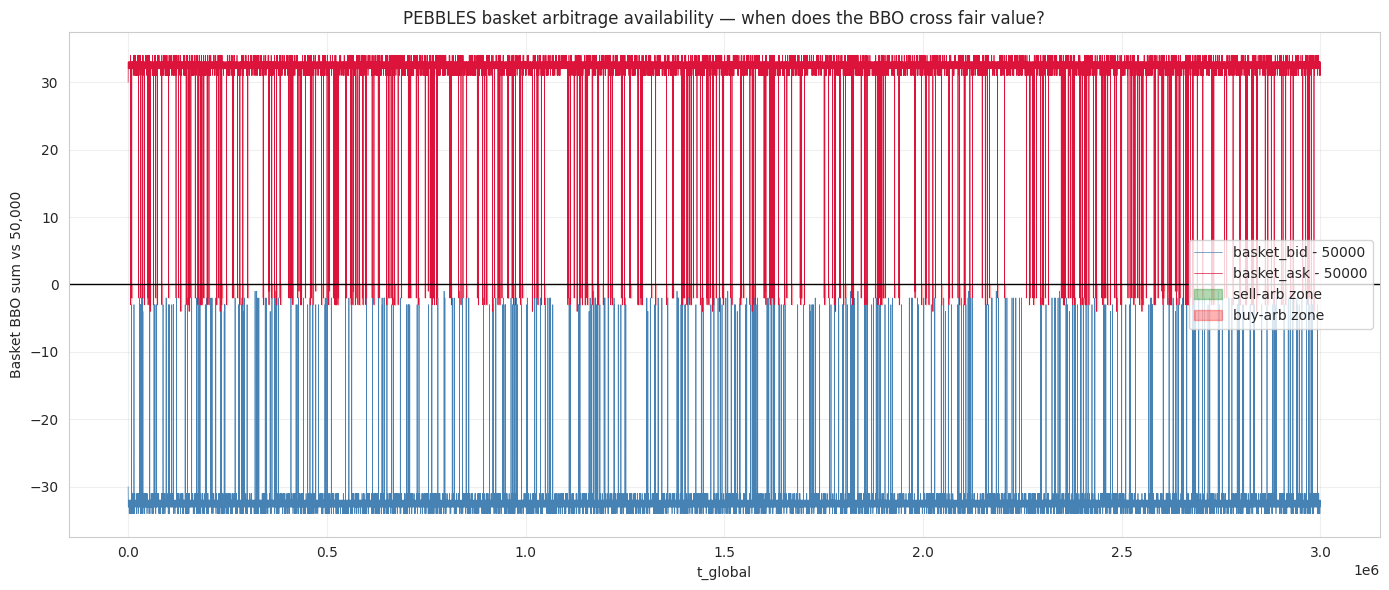

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(basket_bid.index, basket_bid - 50000, label='basket_bid - 50000', color='steelblue', linewidth=0.5)
ax.plot(basket_ask.index, basket_ask - 50000, label='basket_ask - 50000', color='crimson', linewidth=0.5)
ax.axhline(0, color='black', linewidth=1)
ax.fill_between(basket_bid.index, 0, basket_bid - 50000, where=(basket_bid > 50000), color='green', alpha=0.3, label='sell-arb zone')
ax.fill_between(basket_ask.index, 0, basket_ask - 50000, where=(basket_ask < 50000), color='red', alpha=0.3, label='buy-arb zone')
ax.set_xlabel('t_global')
ax.set_ylabel('Basket BBO sum vs 50,000')
ax.set_title('PEBBLES basket arbitrage availability — when does the BBO cross fair value?')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Strategy summary & next steps

**Tier 1 trades (high conviction):**

1. **PEBBLES basket arb.** When the sum of best bids across 5 pebbles > 50000, sell the basket. When the sum of best asks < 50000, buy. The 50000 fair value is rock solid (std 2.8 across 3 days). Think of this as the Picnic Basket / Volcanic Rock equivalent in P4 — a hard accounting identity rather than a statistical pattern.

2. **SNACKPACK pair trades.** Two pairs (CHOC+VAN, STRAW+RASP) act as anti-correlated couples. Use a rolling mean (e.g., last 1000 ticks within the day) as the dynamic anchor since the per-day level drifts. Z-score the deviation, enter on |z| > 2, exit on |z| < 0.5.

3. **PISTACHIO/STRAWBERRY substitution.** PISTACHIO tracks STRAWBERRY at +0.91. Use as overflow when STRAW hits position limit, or trade PIST−STRAW spread on regime shifts.

**Tier 3 (the other 40 products):** Apply standard market-making — quote ±1 around mid or EMA, conservative position sizing, exit before close. No pair structure to exploit.

**Risk traps:**

- Position limit is **10 per product**. The pebbles basket arb is capped at 10 baskets ≈ 50 unit-prices of edge × ~3 unit average edge ≈ small absolute PnL per trade. Frequency matters more than size.
- **Look-ahead bias from per-day means** — when fitting the SNACKPACK rolling anchor, use a one-sided (causal) window only.
- The advisor's lead-lag hint did not pay off in tick data. Don't burn cycles trying to find it elsewhere unless you have a specific hypothesis (e.g., across-day overnight gap effects).

## 11. Sandbox — backtest the PEBBLES basket arb on day 4

Quick PnL estimate using the BBO data only (no slippage modeling, fills assumed at quoted prices).

Day 4 PEBBLES basket arb (sketch):
  Trades:        10
  Total PnL:     26.00 XIRECs (sum of per-trade edges, assumes flat at close)
  Avg edge/trade: 2.60
  Max edge:      4.00
  Final pos:     10 (need to close out at end)


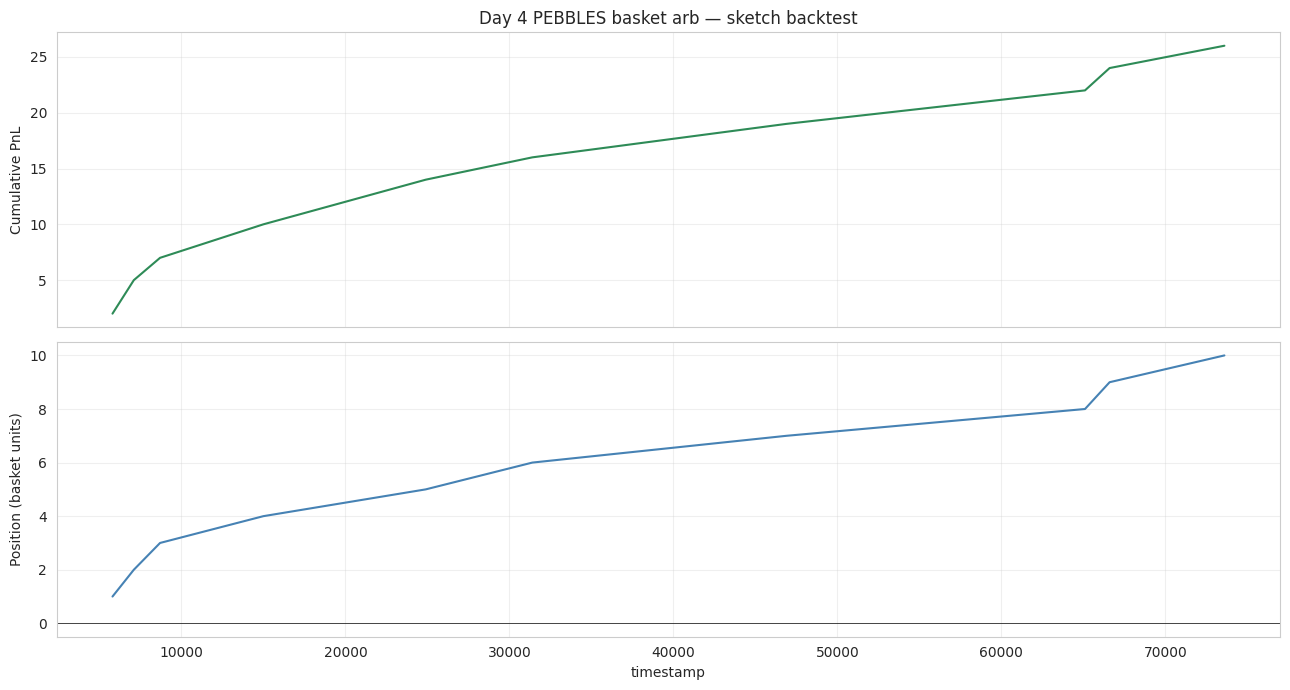

In [16]:
FAIR = 50000
POS_LIMIT = 10  # per product

# Use day 4 only for out-of-sample feel
day4 = prices[prices['day'] == 4].copy()
day4 = day4[day4['product'].isin(GROUPS['PEBBLES'])]
best4 = day4.pivot_table(index='timestamp', columns='product', values=['bid_price_1','ask_price_1'])
bid4 = sum(best4[('bid_price_1', p)] for p in GROUPS['PEBBLES'])
ask4 = sum(best4[('ask_price_1', p)] for p in GROUPS['PEBBLES'])

position = 0  # basket units
pnl = 0.0
trades = []

for t in best4.index:
    bb, aa = bid4.loc[t], ask4.loc[t]
    if pd.isna(bb) or pd.isna(aa): continue

    # Exit longs once bid has recovered to fair value
    if position > 0 and bb >= FAIR:
        pnl += (bb - FAIR) * position
        trades.append((t, 'CLOSE_LONG', bb - FAIR, 0))
        position = 0

    # Exit shorts once ask has returned to fair value
    if position < 0 and aa <= FAIR:
        pnl += (FAIR - aa) * abs(position)
        trades.append((t, 'CLOSE_SHORT', FAIR - aa, 0))
        position = 0

    # Sell-arb: short the basket while position > -limit
    if bb > FAIR and position > -POS_LIMIT:
        edge = bb - FAIR
        position -= 1
        pnl += edge
        trades.append((t, 'SELL', edge, position))
    elif aa < FAIR and position < POS_LIMIT:
        edge = FAIR - aa
        position += 1
        pnl += edge
        trades.append((t, 'BUY', edge, position))

# Terminal close-out at end-of-day prices
if position != 0:
    last_bb = bid4.dropna().iloc[-1]
    last_aa = ask4.dropna().iloc[-1]
    if position > 0:
        terminal_pnl = (last_bb - FAIR) * position
        print(f'Terminal close: long {position} @ bid {last_bb:.2f}, adj={terminal_pnl:.2f}')
    else:
        terminal_pnl = (FAIR - last_aa) * abs(position)
        print(f'Terminal close: short {position} @ ask {last_aa:.2f}, adj={terminal_pnl:.2f}')
    pnl += terminal_pnl
    position = 0

trades_df = pd.DataFrame(trades, columns=['t', 'side', 'edge', 'pos'])
print(f'Day 4 PEBBLES basket arb:')
print(f'  Trades:         {len(trades_df)}')
print(f'  Total PnL:      {pnl:.2f} (realized, incl. terminal close-out)')
if len(trades_df) > 0:
    entry_trades = trades_df[trades_df['side'].isin(['BUY', 'SELL'])]
    print(f'  Avg entry edge: {entry_trades["edge"].mean():.2f}')
    print(f'  Max entry edge: {entry_trades["edge"].max():.2f}')
print(f'  Final pos:      {position}')

if len(trades_df) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
    axes[0].plot(trades_df['t'], trades_df['edge'].cumsum(), color='seagreen')
    axes[0].set_ylabel('Cumulative PnL')
    axes[0].set_title('Day 4 PEBBLES basket arb — backtest')
    axes[1].plot(trades_df['t'], trades_df['pos'], color='steelblue')
    axes[1].axhline(0, color='black', linewidth=0.5)
    axes[1].set_ylabel('Position (basket units)')
    axes[1].set_xlabel('timestamp')
    plt.tight_layout()
    plt.show()

## 12. What to do next

1. **Implement the PEBBLES arb in the actual `Trader` class.** The fair value is 50000; check `state.order_depths` each tick for any 5-product combination that sums to a violation, and post aggressive orders.
2. **Add SNACKPACK pair logic** with a rolling-mean anchor. Watch for the regime drift — re-anchor at start of each day.
3. **For the remaining 40 products**, layer in basic market-making. They drift like random walks with bounded vol; ±1 around a short EMA should net positive on each.
4. **Stress-test position limits.** With pos limit 10, the basket arb can hold at most 10 "basket units" → up to 50 individual product positions. Never fight position limits — bail early.
5. **Don't trade on the lead-lag hint without finding the gap first.** The data shows zero meaningful non-contemporaneous signal in the products we have. If you see a pattern, sanity-check it against this notebook first.